# Day 04 - Understanding the Target Column

Today we are going to deeply understand our target column — SeriousDlqin2yrs

This column tells us:
- 1 = this person defaulted (missed payments for 90+ days)
- 0 = this person did NOT default

We want to find out:
- How many people defaulted vs did not?
- Which age group defaults the most?
- Does higher income mean less default?
- Which features look different between defaulters and non-defaulters?

## Step 1 - Import libraries and load data

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [49]:
df = pd.read_csv('cs-training-day3-cleaned.csv', index_col=0)

In [50]:
df.shape

(149999, 12)

In [51]:
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,income_is_missing
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0,0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0,0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0,0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0,0
5,0,0.907239,49,1,0.024926,23000.0,7,0,1,0,0.0,0


## Step 2 - How many people defaulted vs did not?

Let's just count how many 0s and 1s are in our target column

In [5]:
df['SeriousDlqin2yrs'].value_counts()

SeriousDlqin2yrs
0    139973
1     10026
Name: count, dtype: int64

So we can see most people did NOT default (0) and only a few did (1)

Let's see this in percentage

In [6]:
df['SeriousDlqin2yrs'].value_counts(normalize=True) * 100

SeriousDlqin2yrs
0    93.315955
1     6.684045
Name: proportion, dtype: float64

Now let's plot this so it's easier to see

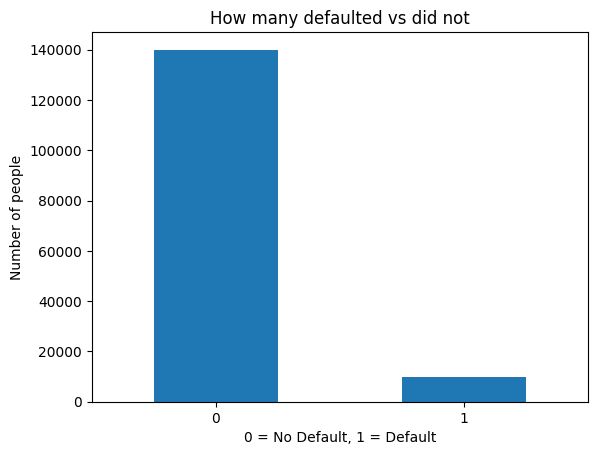

In [30]:
df['SeriousDlqin2yrs'].value_counts().plot(kind='bar' , rot = 0)
plt.title('How many defaulted vs did not')
plt.xlabel('0 = No Default, 1 = Default')
plt.ylabel('Number of people')
plt.show()

## Step 3 - Split data into two groups

To compare defaulters vs non-defaulters, let's just split them into two separate dataframes.
This makes it easy to compare.

In [8]:
defaulters = df[df['SeriousDlqin2yrs'] == 1]
non_defaulters = df[df['SeriousDlqin2yrs'] == 0]

In [9]:
print('Number of defaulters:', len(defaulters))
print('Number of non defaulters:', len(non_defaulters))

Number of defaulters: 10026
Number of non defaulters: 139973


## Step 4 - Compare average age

Let's first check - is there an age difference between the two groups?

In [10]:
print('Average age of defaulters:', defaulters['age'].mean())
print('Average age of non defaulters:', non_defaulters['age'].mean())

Average age of defaulters: 45.92659086375424
Average age of non defaulters: 52.751752123623845


Let's plot the age distribution of both groups side by side

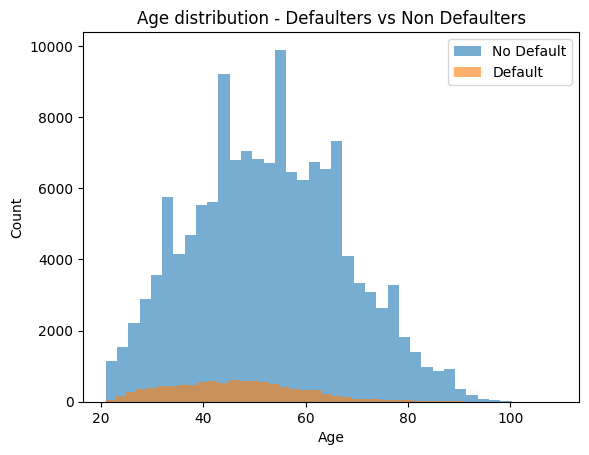

In [31]:
plt.hist(non_defaulters['age'], bins=40, alpha=0.6, label='No Default')
plt.hist(defaulters['age'], bins=40, alpha=0.6, label='Default')
plt.title('Age distribution - Defaulters vs Non Defaulters')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend()
plt.show()

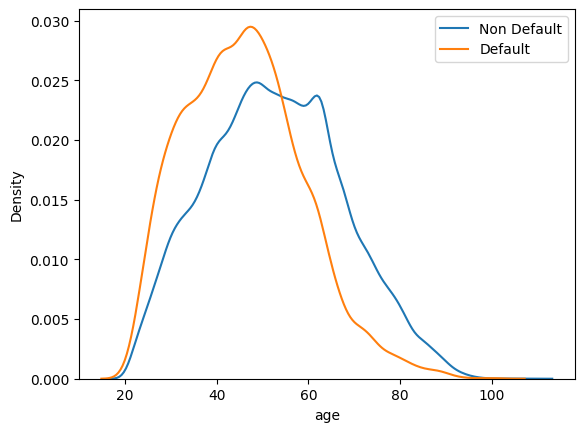

skew ness of nondefault 0.16
skew ness of default 0.46


In [41]:
sns.kdeplot(non_defaulters['age'] , label = 'Non Default')
sns.kdeplot(defaulters['age'] , label = 'Default')
plt.legend()
plt.show()
print('skew ness of nondefault',np.round(non_defaulters['age'].skew() , 2 ))
print('skew ness of default',np.round(defaulters['age'].skew() , 2))

## Step 5 - Which age group defaults the most?

Let's create age groups manually and check default rate in each group

In [57]:
# Create age groups
df['age_group'] = pd.cut(df['age'], bins=[18, 30, 40, 50, 60, 100], labels=['18-30', '30-40', '40-50', '50-60', '60+'])

In [58]:
# Check how many people in each age group
df['age_group'].value_counts()

age_group
60+      45047
40-50    35037
50-60    34806
30-40    24339
18-30    10757
Name: count, dtype: int64

In [60]:
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,income_is_missing,age_group
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0,0,40-50
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0,0,30-40
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0,0,30-40
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0,0,18-30
5,0,0.907239,49,1,0.024926,23000.0,7,0,1,0,0.0,0,40-50


In [59]:
# Now check default rate per age group
# .mean() on a 0/1 column gives us the percentage who defaulted
default_by_age = df.groupby('age_group')['SeriousDlqin2yrs'].mean() * 100
default_by_age

C:\Users\PUSKAR\AppData\Local\Temp\ipykernel_10520\46997217.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  default_by_age = df.groupby('age_group')['SeriousDlqin2yrs'].mean() * 100


age_group
18-30    11.564563
30-40     9.819631
40-50     8.256985
50-60     6.174223
60+       2.994650
Name: SeriousDlqin2yrs, dtype: float64

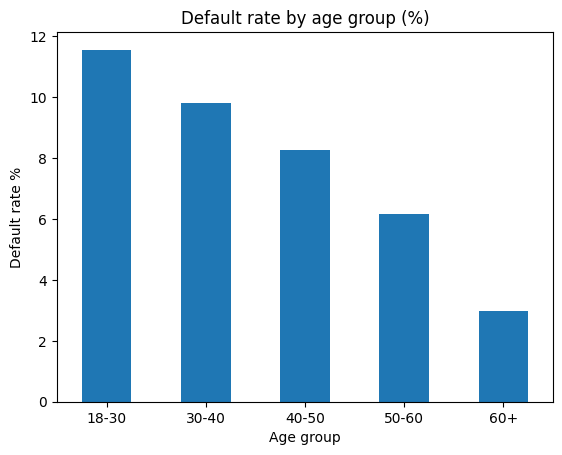

In [15]:
default_by_age.plot(kind='bar')
plt.title('Default rate by age group (%)')
plt.xlabel('Age group')
plt.ylabel('Default rate %')
plt.xticks(rotation=0)
plt.show()

Write down what you observe here:
- Which age group has the highest default rate : we cobserve that most of 18-30  age groups are defaukted rather than the older age group
- Which age group is the safest : 60+
- Does this make sense in real life : Yes. This observation is reasonable because younger individuals (18–30 years) often have lower income stability.

## Step 6 - Does income affect default rate?

Let's check average income of defaulters vs non-defaulters

In [61]:
print('Average income of defaulters:', defaulters['MonthlyIncome'].mean())
print('Average income of non defaulters:', non_defaulters['MonthlyIncome'].mean())

Average income of defaulters: 5428.871932974267
Average income of non defaulters: 6193.558236231273


Now let's create income brackets and check default rate in each

In [63]:
# qcut divides into 4 equal groups automatically
df['income_group'] = pd.qcut(df['MonthlyIncome'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])

In [64]:
default_by_income = df.groupby('income_group')['SeriousDlqin2yrs'].mean() * 100
default_by_income

C:\Users\PUSKAR\AppData\Local\Temp\ipykernel_10520\1145030989.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  default_by_income = df.groupby('income_group')['SeriousDlqin2yrs'].mean() * 100


income_group
Low          9.052609
Medium       6.518471
High         6.360502
Very High    4.733585
Name: SeriousDlqin2yrs, dtype: float64

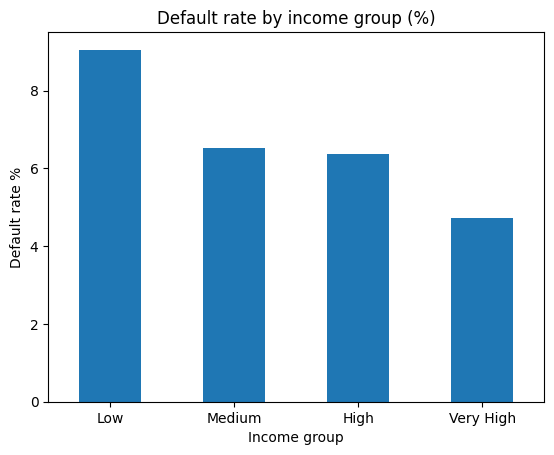

In [19]:
default_by_income.plot(kind='bar')
plt.title('Default rate by income group (%)')
plt.xlabel('Income group')
plt.ylabel('Default rate %')
plt.xticks(rotation=0)
plt.show()

Write down what you observe:
- Does higher income mean less default : Yes. The default rate generally decreases as monthly income increases.
- Is the difference big or small : Borrowers in the low-income category have a default rate of around 9%, compared to approximately 6% for the medium- and high-income categories and about 4% for the very high-income category.

## Step 7 - Compare late payment history

Intuitively, people who missed payments before should be more likely to default.
Let's verify this.

In [65]:
print('Average 90-day late payments - defaulters:', defaulters['NumberOfTimes90DaysLate'].mean()*100)
print('Average 90-day late payments - non defaulters:', non_defaulters['NumberOfTimes90DaysLate'].mean()*100)

Average 90-day late payments - defaulters: 79.97207261121085
Average 90-day late payments - non defaulters: 5.83683996199267


In [67]:
print('Average 30-59 day late payments - defaulters:', defaulters['NumberOfTime30-59DaysPastDueNotWorse'].mean()*100)
print('Average 30-59 day late payments - non defaulters:', non_defaulters['NumberOfTime30-59DaysPastDueNotWorse'].mean()*100)

Average 30-59 day late payments - defaulters: 109.84440454817475
Average 30-59 day late payments - non defaulters: 20.340351353475313


Let's plot the 90-day late payment comparison

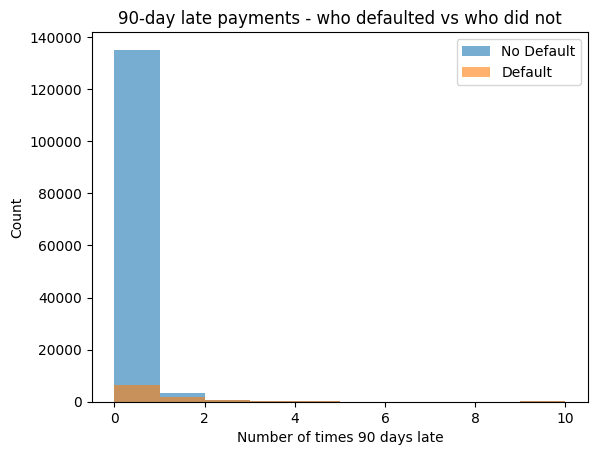

In [68]:
plt.hist(non_defaulters['NumberOfTimes90DaysLate'], bins=10, alpha=0.6, label='No Default')
plt.hist(defaulters['NumberOfTimes90DaysLate'], bins=10, alpha=0.6, label='Default')
plt.title('90-day late payments - who defaulted vs who did not')
plt.xlabel('Number of times 90 days late')
plt.ylabel('Count')
plt.legend()
plt.show()

## Step 8 - Compare utilization rate

Utilization = how much of your credit limit you are using
High utilization means you are spending close to your limit = risky

In [70]:
print('Average utilization - defaulters:', defaulters['RevolvingUtilizationOfUnsecuredLines'].mean()*100)
print('Average utilization - non defaulters:', non_defaulters['RevolvingUtilizationOfUnsecuredLines'].mean()*100)

Average utilization - defaulters: 70.21217306950928
Average utilization - non defaulters: 29.576298782575925


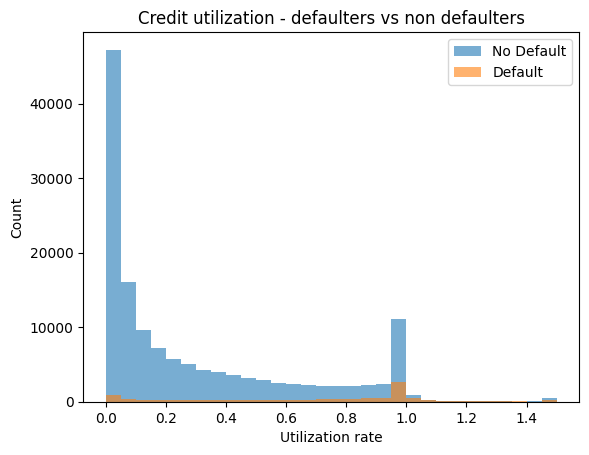

In [71]:
plt.hist(non_defaulters['RevolvingUtilizationOfUnsecuredLines'], bins=30, alpha=0.6, label='No Default')
plt.hist(defaulters['RevolvingUtilizationOfUnsecuredLines'], bins=30, alpha=0.6, label='Default')
plt.title('Credit utilization - defaulters vs non defaulters')
plt.xlabel('Utilization rate')
plt.ylabel('Count')
plt.legend()
plt.show()

## Step 9 - Summary: Which features look most different between the two groups?

Let's compare ALL features at once between defaulters and non-defaulters.
A big difference = that feature is likely important for predicting default.

In [72]:
# Compare mean values of all columns between the two groups
comparison = pd.DataFrame({
    'Non Defaulter avg': non_defaulters.mean(),
    'Defaulter avg': defaulters.mean()
})

comparison

,Non Defaulter avg,Defaulter avg
SeriousDlqin2yrs,0.000000,1.000000
RevolvingUtilizationOfUnsecuredLines,0.295763,0.702122
age,52.751752,45.926591
NumberOfTime30-59DaysPastDueNotWorse,0.203404,1.098444
DebtRatio,320.782163,257.485365
MonthlyIncome,6193.558236,5428.871933
NumberOfOpenCreditLinesAndLoans,8.493638,7.882306
NumberOfTimes90DaysLate,0.058368,0.799721
NumberRealEstateLoansOrLines,1.020361,0.988530
NumberOfTime60-89DaysPastDueNotWorse,0.049981,0.538500


In [73]:
# Calculate how different they are (ratio)
comparison['difference ratio'] = comparison['Defaulter avg'] / comparison['Non Defaulter avg']
comparison = comparison.sort_values('difference ratio', ascending=False)
comparison

,Non Defaulter avg,Defaulter avg,difference ratio
SeriousDlqin2yrs,0.000000,1.000000,inf
NumberOfTimes90DaysLate,0.058368,0.799721,13.701262
NumberOfTime60-89DaysPastDueNotWorse,0.049981,0.538500,10.774078
NumberOfTime30-59DaysPastDueNotWorse,0.203404,1.098444,5.400320
RevolvingUtilizationOfUnsecuredLines,0.295763,0.702122,2.373934
NumberOfDependents,0.723518,0.931279,1.287153
NumberRealEstateLoansOrLines,1.020361,0.988530,0.968804
NumberOfOpenCreditLinesAndLoans,8.493638,7.882306,0.928025
MonthlyIncome,6193.558236,5428.871933,0.876535
age,52.751752,45.926591,0.870617


Features with the highest ratio = biggest difference between defaulters and non-defaulters.
These will likely be our most important features in the model.

Write down the top 3 features here:
1. NumberOfTimes90DaysLate	
2. NumberOfTime60-89DaysPastDueNotWorse	
3. RevolvingUtilizationOfUnsecuredLines	

## Step 10 - Why accuracy is a bad metric here (important concept)

Let's prove this with actual numbers

In [75]:
total = len(df)
non_default_count = len(non_defaulters)

# If a model just says NO DEFAULT for everyone, what accuracy does it get?
dummy_accuracy = (non_default_count / total) * 100

print('Total people:', total)
print('Non defaulters:', non_default_count)
print()
print('If model says NO DEFAULT for everyone...')
print('Accuracy would be:', round(dummy_accuracy, 2), '%')
print()
print('But it would catch 0 actual defaulters!')
print('This is why we use AUC-ROC instead of accuracy')

Total people: 149999
Non defaulters: 139973

If model says NO DEFAULT for everyone...
Accuracy would be: 93.32 %

But it would catch 0 actual defaulters!
This is why we use AUC-ROC instead of accuracy


## Step 11 - Save cleaned data and clean up temp columns

In [76]:
# Remove the temp columns we created today
df = df.drop(columns=['age_group', 'income_group'])

In [77]:
df.to_csv('cs-training-day4-cleaned.csv')
print('Saved!')

Saved!


## My observations today (fill this yourself)

1. The age group with highest default rate is: ?
2. Income and default rate relationship: ?
3. The feature most different between defaulters and non-defaulters: ?
4. One thing that surprised me: ?

---
Tomorrow - Day 05: Correlation between features